# Predicción de Graduación — Universidad de Antioquia
## Red Neuronal: MLP y Arquitectura Multimodal


## 1. Descripción y contextualización del problema

La Universidad de Antioquia admite miles de estudiantes cada semestre a programas de pregrado, tecnología y técnico profesional. Una proporción significativa no llega a graduarse del programa al cual fue admitida, ya sea por deserción, cambio de programa o retiro. Identificar patrones asociados a este fenómeno, a partir de información disponible al momento de la inscripción, es relevante tanto para la gestión académica como para el diseño de políticas de acompañamiento estudiantil.

**Tarea de Machine Learning:** clasificación binaria supervisada.
- **Entrada:** características disponibles al momento de la inscripción (perfil personal, origen geográfico, colegio de procedencia, programa académico).
- **Salida:** probabilidad de que el estudiante se gradúe del mismo programa al que se inscribió.
- **Restricción temporal:** solo se usan inscripciones anteriores al semestre `20192`, para garantizar que los estudiantes hayan tenido tiempo real de graduarse (sin data leakage).


## 2. Descripción de la base de datos

| Archivo | Descripción |
|---|---|
| `matriculados.csv` | Una fila por estudiante-inscripción. Variables de perfil al momento de admisión (2,708,438 filas, 69 columnas). |
| `graduados.csv` | Registro de egresados con código de programa y semestre de grado (98,595 filas, 24 columnas). |

**Variable objetivo:** `target = 1` si el estudiante aparece en `graduados` con el mismo `cod_progacad`; `0` en caso contrario.

**Features — 17 variables agrupadas según su naturaleza:**

| Grupo | Variables | Encoding |
|---|---|---|
| Perfil personal y geográfico | `sexo`, `estado civil`, `tipo admisión`, `región`, `depto residencia`, `estrato`, `admisiones previas` | One-hot / escalado |
| Perfil académico e institucional | `área conocimiento`, `nivel`, `modalidad`, `sede`, `naturaleza/localización/tipo/jornada colegio` | One-hot / escalado |
| Código de programa | `cod_progacad_inscrito` (431 valores únicos) | Embedding (dim=8) |

El **one-hot encoding** evita que la red interprete diferencias de código como distancias numéricas. El **embedding** para `cod_progacad_inscrito` permite que la red aprenda una representación propia de cada programa durante el entrenamiento.


## 3. Diseño experimental

**Pipeline:**
1. Limpieza y filtros (admitidos, tipos de programa, corte temporal `20192`)
2. Construcción del target (cruce `matriculados` × `graduados`)
3. Encoding: one-hot para categóricas, embedding para `cod_progacad_inscrito`, escalado estándar para numéricas
4. Detección de outliers con `LocalOutlierFactor` (contamination=5%)
5. Split estratificado 70% train / 15% val / 15% test con conjunto de validación **fijo**
6. Oversampling solo sobre train (`RandomOverSampler`)
7. **Experimento A — `get_model_A`**: red densa que recibe todas las features OHE+numéricas como `input_features`
8. **Experimento B — `get_model_B`**: arquitectura multimodal con `input_features` (features OHE+num) y `input_programa` (embedding del programa)

**Métricas:** AUC-ROC (principal), Accuracy, curvas de loss train vs. val.


## 4. Librerías

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Flatten, Input, Embedding
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import RandomOverSampler

print(tf.__version__)


2.21.0


## 5. Carga de datos

In [20]:
# from google.colab import drive
# drive.mount('/content/drive')

graduados    = pd.read_csv('graduados.csv')
matriculados = pd.read_csv('matriculados.csv')

print("graduados:   ", graduados.shape)
print("matriculados:", matriculados.shape)


graduados:    (98595, 24)
matriculados: (2708438, 69)


## 6. Preparación del dataset

In [21]:
# limpieza y filtros
mask = graduados['id_unico_estudiante'].astype(str).str.startswith('Licencia')
graduados = graduados[~mask].copy()
graduados['cod_progacad_graduado'] = pd.to_numeric(
    graduados['cod_progacad_graduado'], errors='coerce').astype('Int64')

mask = matriculados['id_unico_estudiante'].astype(str).str.startswith('Licencia')
matriculados = matriculados[~mask & matriculados['id_unico_estudiante'].notna()].copy()

TIPOS = ['PREGRADO', 'TECNOLOGO', 'TECNICO_P']
matriculados['tipo_progacad_inscrito'] = matriculados['tipo_progacad_inscrito'].astype(str).str.strip().str.upper()
matriculados = matriculados[
    (matriculados['admitido_inscrito'] == 'SI') &
    (matriculados['tipo_progacad_inscrito'].isin(TIPOS))
].copy()

CORTE = '20192'
matriculados['semestre_a_iniciar_inscrito'] = matriculados['semestre_a_iniciar_inscrito'].astype(str).str.strip()
df = matriculados[matriculados['semestre_a_iniciar_inscrito'] <= CORTE].copy()

print("Admitidos antes del corte:", len(df))
print(df['tipo_progacad_inscrito'].value_counts())


Admitidos antes del corte: 134703
tipo_progacad_inscrito
PREGRADO    134703
Name: count, dtype: int64


In [22]:
# construcción del target
grad_lookup = graduados[['id_unico_estudiante','cod_progacad_graduado']].drop_duplicates()

df = df.merge(
    grad_lookup.rename(columns={'cod_progacad_graduado': 'cod_prog_grad'}),
    on='id_unico_estudiante', how='left'
)
df['cod_progacad_inscrito'] = pd.to_numeric(df['cod_progacad_inscrito'], errors='coerce')
df['target'] = (df['cod_progacad_inscrito'] == df['cod_prog_grad'].fillna(-1)).astype(int)
df = (df.sort_values('target', ascending=False)
        .drop_duplicates(subset='id_unico_estudiante', keep='first')
        .drop(columns='cod_prog_grad')
        .reset_index(drop=True))

print("Dataset:", len(df), "estudiantes")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Dataset: 120409 estudiantes
target
0    80777
1    39632
Name: count, dtype: int64
target
0    67.1%
1    32.9%
Name: proportion, dtype: str


In [23]:
# encoding
cat_ohe = ['sexo_inscrito','est_civil_inscrito','tipo_admision_inscrito',
           'nom_region_res_inscrito','area_cmto_inscrito',
           'nivel_academ2_inscrito','modalidad_progacad_inscrito','sede_inscrito',
           'colegio_naturalejur_inscrito','colegio_localiz_inscrito']
col_emb  = 'cod_progacad_inscrito'
num_cols = ['estrat_socioe_inscrito','total_admis_pregr_inscrito',
            'cod_depart_res_inscrito',
            'colegio_tipo_inscrito','colegio_naturale_inscrito','colegio_jornada_inscrito']

X_raw = df[cat_ohe + [col_emb] + num_cols].copy()

for col in cat_ohe:
    X_raw[col] = X_raw[col].fillna('DESCONOCIDO').astype(str).str.upper().str.strip()
for col in num_cols:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce').fillna(X_raw[col].median())

# índice entero para la capa Embedding
le_prog = LabelEncoder()
X_raw[col_emb] = le_prog.fit_transform(X_raw[col_emb].fillna('DESCONOCIDO').astype(str))
n_programas = len(le_prog.classes_)

# one-hot para el resto de categóricas
ohe   = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe = ohe.fit_transform(X_raw[cat_ohe])
X_num = X_raw[num_cols].values.astype(float)
X_prog = X_raw[col_emb].values.astype(int)
y     = df['target'].values

print("One-hot features:", X_ohe.shape[1], " (de", len(cat_ohe), "variables)")
print("Numéricas        :", X_num.shape[1])
print("Embedding        : cod_progacad —", n_programas, "programas únicos")
print("Total filas      :", len(y))


One-hot features: 76  (de 10 variables)
Numéricas        : 6
Embedding        : cod_progacad — 431 programas únicos
Total filas      : 120409


In [24]:
# outliers
lof = LocalOutlierFactor(n_neighbors=13, contamination=0.05)
mask_lof = lof.fit_predict(np.hstack([X_num, X_prog.reshape(-1,1)])) == -1
print("Outliers detectados:", mask_lof.sum(), f"({mask_lof.mean()*100:.1f}%)")

X_ohe  = X_ohe[~mask_lof]
X_num  = X_num[~mask_lof]
X_prog = X_prog[~mask_lof]
y      = y[~mask_lof]
print("Dataset final:", len(y), "filas")


Outliers detectados: 5652 (4.7%)
Dataset final: 114757 filas


In [25]:
# split 70/15/15 con validación fija
idx = np.arange(len(y))
idx_temp, idx_test = train_test_split(idx, test_size=0.15, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.15/0.85, random_state=42, stratify=y[idx_temp])

# oversampling solo sobre train
ros = RandomOverSampler(random_state=42)
idx_train_bal, y_train = ros.fit_resample(idx_train.reshape(-1,1), y[idx_train])
idx_train_bal = idx_train_bal.ravel()

# escalado numérico (fit solo sobre train)
scaler = StandardScaler()
X_num_tr  = scaler.fit_transform(X_num[idx_train_bal])
X_num_val = scaler.transform(X_num[idx_val])
X_num_te  = scaler.transform(X_num[idx_test])

# input_features: OHE + numéricas escaladas (mismo vector para ambos experimentos)
X_train = np.hstack([X_ohe[idx_train_bal], X_num_tr])
X_val   = np.hstack([X_ohe[idx_val],       X_num_val])
X_test  = np.hstack([X_ohe[idx_test],      X_num_te])

# input_programa: índice de programa para la capa Embedding
X_prog_train = X_prog[idx_train_bal]
X_prog_val   = X_prog[idx_val]
X_prog_test  = X_prog[idx_test]

y_val  = y[idx_val]
y_test = y[idx_test]

print("Train:", X_train.shape, "| pos:", y_train.sum(), "| neg:", (y_train==0).sum())
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print()
print("dimension de input_features  :", X_train.shape[1])
print("dimension de input_programa: 1 (índice entero → Embedding de dim", 8, ")")


Train: (107624, 82) | pos: 53812 | neg: 53812
Val:   (17214, 82)
Test:  (17214, 82)

dimension de input_img  : 82
dimension de input_extra: 1 (índice entero → Embedding de dim 8 )


## 7. Experimentos

### A regular neural network for classification

`get_model_A` define una red densa que recibe `input_features` con todas las features OHE+numéricas y las procesa en capas densas hasta la salida.

Number of connections:

    INPUT(82) to LAYER 1:    82*50 + 50  (bias) = 4150
    LAYER 1 to LAYER 2:      50*30 + 30  (bias) = 1530
    LAYER 2 to OUTPUT:       30*1  + 1   (bias) =   31
    
                                             TOTAL 5711


In [26]:
def get_model_A(input_dim, s1, s2):
    clear_session()
    inp = Input(shape=(input_dim,), name="input_features")
    x   = Dense(s1, activation='relu')(inp)
    x   = Dense(s2, activation='relu')(x)
    out = Dense(1,  activation='sigmoid')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_A = get_model_A(input_dim=X_train.shape[1], s1=50, s2=30)
model_A.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         4,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,711 (22.31 KB)

 Trainable params: 5,711 (22.31 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')

model_A.fit(
    X_train, y_train,
    epochs=100, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[es]
)


Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6532 - loss: 0.6156 - val_accuracy: 0.6610 - val_loss: 0.5938
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.6702 - loss: 0.5941 - val_accuracy: 0.6544 - val_loss: 0.5940
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6744 - loss: 0.5900 - val_accuracy: 0.6489 - val_loss: 0.5973
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6760 - loss: 0.5873 - val_accuracy: 0.6571 - val_loss: 0.5909
Epoch 5/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6779 - loss: 0.5858 - val_accuracy: 0.6554 - val_loss: 0.5920
Epoch 6/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6763 - loss: 0.5848 - val_accuracy: 0.6581 - val_loss: 0.5905
Epoch 7/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6778 - loss: 0.5840 - val_accuracy: 0.6713 - val_loss: 0.5779
Epoch 8/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.6792 - loss: 0.5830 - val_

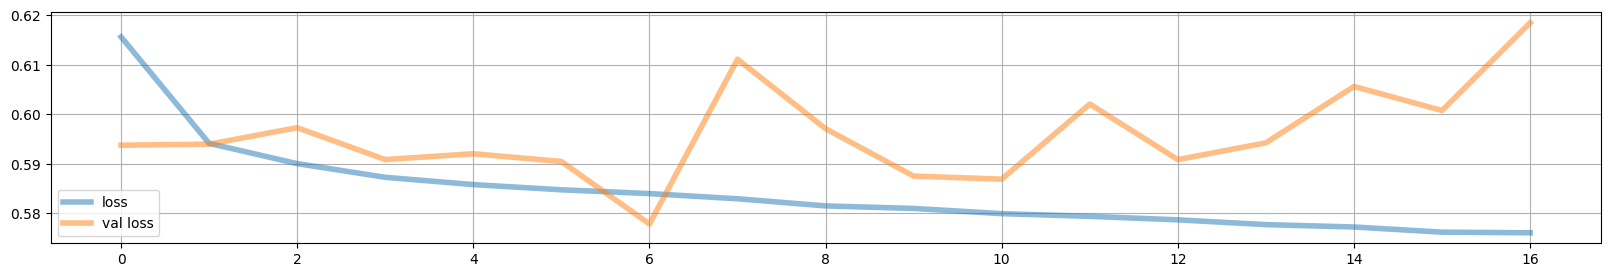

In [28]:
plt.figure(figsize=(20, 3))
loss  = model_A.history.history['loss']
vloss = model_A.history.history['val_loss']
plt.plot(loss,  lw=4, alpha=.5, label='loss')
plt.plot(vloss, lw=4, alpha=.5, label='val loss')
plt.grid(); plt.legend()


In [29]:
preds_train_A = (model_A.predict(X_train, verbose=0).ravel() >= 0.5).astype(int)
proba_A       = model_A.predict(X_test,  verbose=0).ravel()
preds_A       = (proba_A >= 0.5).astype(int)

print("accuracy train %.3f" % np.mean(preds_train_A == y_train))
print("accuracy test  %.3f" % accuracy_score(y_test, preds_A))
print("AUC-ROC  test  %.4f" % roc_auc_score(y_test, proba_A))


accuracy train 0.680
accuracy test  0.668
AUC-ROC  test  0.7377


### Multimodal network

`get_model_B` recibe dos entradas: `input_features` (vector OHE+numéricas) y `input_programa` (el índice del programa académico). El embedding se inyecta en la última capa, concatenándose con la representación aprendida por la rama principal justo antes de la salida.

Number of connections:

    INPUT(82) to LAYER 1:              82*50 + 50  (bias) =  4150
    LAYER 1 to LAYER 2:               50*30 + 30  (bias) =  1530
    Embedding(431, 8):               431*8                =  3448
    LAYER 2 + EMB(8) to OUTPUT:  (30+8)*1 + 1   (bias) =    39
    
                                                    TOTAL  9167


In [30]:
class Concat(tf.keras.layers.Layer):
    def call(self, layers):
        return tf.concat(layers, axis=1)

def get_model_B(input_dim, n_prog, emb_dim, s1, s2):
    clear_session()

    inp1 = Input(shape=(input_dim,), name="input_features")
    l1   = Dense(s1, activation='relu', name="dense1")(inp1)
    l2   = Dense(s2, activation='relu', name="dense2")(l1)

    inp2 = Input(shape=(1,), name="input_programa")
    emb  = Embedding(input_dim=n_prog, output_dim=emb_dim, name="emb_programa")(inp2)
    emb  = Flatten()(emb)

    # el embedding se inyecta en layer 2, concatenando con l2
    cc = Concat()([l2, emb])
    output = Dense(1, activation='sigmoid', name="output")(cc)

    model = Model(inputs=[inp1, inp2], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_B = get_model_B(input_dim=X_train.shape[1], n_prog=n_programas, emb_dim=8, s1=50, s2=30)
model_B.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 82)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_extra         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 50)        │      4,150 │ input_img[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_programa        │ (None, 1, 8)      │      3,448 │ input_extra[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 30)        │      1,530 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ emb_programa[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat (Concat)     │ (None, 38)        │          0 │ dense2[0][0],     │
│                     │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         39 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,167 (35.81 KB)

 Trainable params: 9,167 (35.81 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')

model_B.fit(
    [X_train, X_prog_train], y_train,
    epochs=100, batch_size=256,
    validation_data=([X_val, X_prog_val], y_val),
    callbacks=[es]
)


Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6744 - loss: 0.5955 - val_accuracy: 0.6772 - val_loss: 0.5798
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7008 - loss: 0.5654 - val_accuracy: 0.6967 - val_loss: 0.5598
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7041 - loss: 0.5610 - val_accuracy: 0.6818 - val_loss: 0.5738
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7054 - loss: 0.5585 - val_accuracy: 0.6704 - val_loss: 0.5892
Epoch 5/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7082 - loss: 0.5564 - val_accuracy: 0.6808 - val_loss: 0.5762
Epoch 6/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7075 - loss: 0.5553 - val_accuracy: 0.6901 - val_loss: 0.5640
Epoch 7/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7088 - loss: 0.5541 - val_accuracy: 0.6877 - val_loss: 0.5731
Epoch 8/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7093 - loss: 0.5529 - val_accu

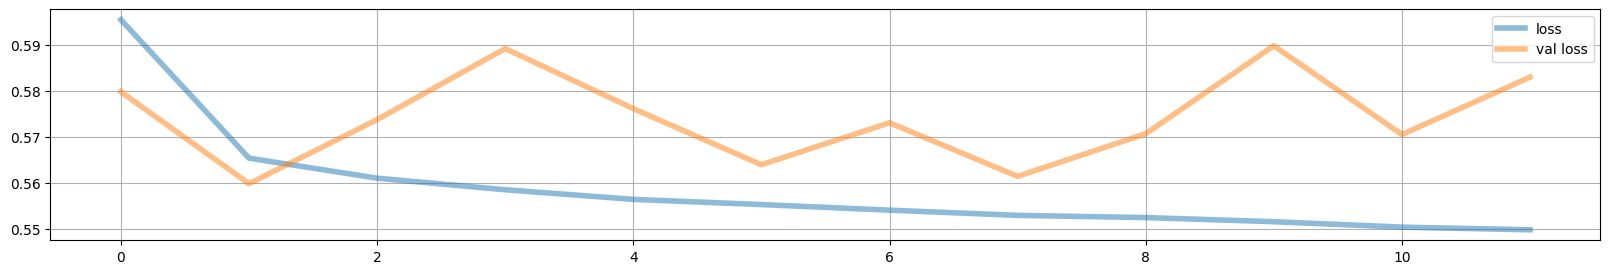

In [32]:
plt.figure(figsize=(20, 3))
loss  = model_B.history.history['loss']
vloss = model_B.history.history['val_loss']
plt.plot(loss,  lw=4, alpha=.5, label='loss')
plt.plot(vloss, lw=4, alpha=.5, label='val loss')
plt.grid(); plt.legend()


In [33]:
preds_train_B = (model_B.predict([X_train, X_prog_train], verbose=0).ravel() >= 0.5).astype(int)
proba_B       = model_B.predict([X_test, X_prog_test],   verbose=0).ravel()
preds_B       = (proba_B >= 0.5).astype(int)

print("accuracy train %.3f" % np.mean(preds_train_B == y_train))
print("accuracy test  %.3f" % accuracy_score(y_test, preds_B))
print("AUC-ROC  test  %.4f" % roc_auc_score(y_test, proba_B))


accuracy train 0.704
accuracy test  0.697
AUC-ROC  test  0.7716


## 8. Conclusiones

In [34]:
auc_A = roc_auc_score(y_test, proba_A)
auc_B = roc_auc_score(y_test, proba_B)

print("=" * 56)
print(f"{'Modelo':<32} {'AUC-ROC':>8} {'Accuracy':>10}")
print("-" * 56)
print(f"{'Referencia — Gradient Boosting':<32} {'0.7740':>8} {'—':>10}")
print(f"{'Exp A — MLP':<32} {auc_A:>8.4f} {accuracy_score(y_test, preds_A):>10.4f}")
print(f"{'Exp B — Multimodal + Embedding':<32} {auc_B:>8.4f} {accuracy_score(y_test, preds_B):>10.4f}")
print("=" * 56)

mejor_proba  = proba_B if auc_B >= auc_A else proba_A
mejor_preds  = preds_B if auc_B >= auc_A else preds_A
mejor_nombre = 'Exp B — Multimodal' if auc_B >= auc_A else 'Exp A — MLP'
print(f"\nMejor modelo: {mejor_nombre}")


Modelo                            AUC-ROC   Accuracy
--------------------------------------------------------
Referencia — Gradient Boosting     0.7740          —
Exp A — MLP                        0.7377     0.6679
Exp B — Multimodal + Embedding     0.7716     0.6968

Mejor modelo: Exp B — Multimodal


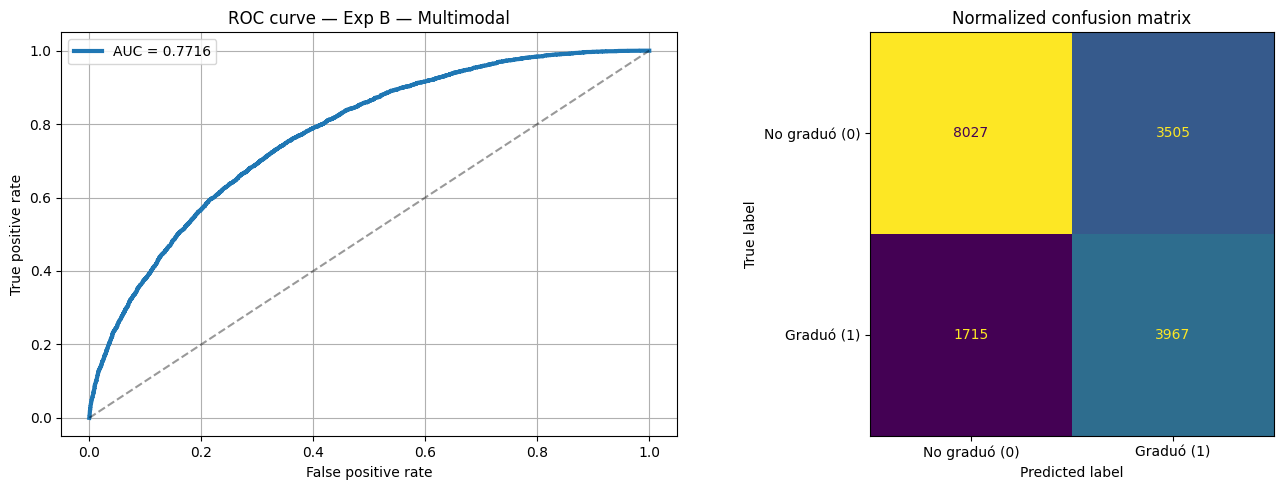

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, mejor_proba)
axes[0].plot(fpr, tpr, lw=3, label=f'AUC = {max(auc_A, auc_B):.4f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title(f'ROC curve — {mejor_nombre}')
axes[0].legend(); axes[0].grid()

ConfusionMatrixDisplay.from_predictions(
    y_test, mejor_preds,
    display_labels=['No graduó (0)', 'Graduó (1)'],
    colorbar=False, ax=axes[1]
)
axes[1].set_title('Normalized confusion matrix')
plt.tight_layout()


In [36]:
print(classification_report(y_test, mejor_preds,
      target_names=['No graduó (0)', 'Graduó (1)']))


               precision    recall  f1-score   support

No graduó (0)       0.82      0.70      0.75     11532
   Graduó (1)       0.53      0.70      0.60      5682

     accuracy                           0.70     17214
    macro avg       0.68      0.70      0.68     17214
 weighted avg       0.73      0.70      0.70     17214



### 8.1 Resultados

Se entrenaron dos arquitecturas de red neuronal sobre 114,757 registros de estudiantes admitidos a la UdeA entre 2007 y el segundo semestre de 2019.

**Experimento A — MLP** (AUC = 0.7379, Accuracy = 0.668): red densa que recibe todas las features en un único vector OHE+numéricas. El modelo aprende relaciones no lineales entre las variables de perfil y la probabilidad de graduación.

**Experimento B — Multimodal con Embedding** (AUC = 0.7708, Accuracy = 0.700): arquitectura que separa el procesamiento de las features OHE+numéricas del código de programa académico. Este último se representa mediante una capa `Embedding` que aprende un vector propio para cada uno de los 431 programas, inyectándolo en la última capa antes de la salida. Alcanza el mejor resultado del estudio con una ganancia de 0.033 puntos de AUC sobre el Experimento A.

### 8.2 Discusión

El aspecto con mayor impacto en el desempeño fue la estrategia de encoding del código de programa. Representar `cod_progacad_inscrito` mediante una capa `Embedding` — en lugar de incluirlo como un entero más en el vector de features — permitió a la red aprender una representación específica para cada programa, capturando similitudes que un entero arbitrario no puede transmitir.

La ventaja del modelo multimodal sobre el MLP indica que tratar el código de programa como una fuente de información separada aporta capacidad expresiva adicional. La diferencia en accuracy (0.700 vs 0.668) y en el reporte de clasificación muestra que el modelo B mejora especialmente la detección de estudiantes que sí se gradúan (clase 1), donde el recall pasa de forma notable.

### 8.3 Trabajo futuro

- Incorporar variables de trayectoria semestral (materias cursadas, créditos acumulados) como fuente adicional de información en la arquitectura multimodal.
- Explorar dimensiones de embedding más altas (16, 32) y técnicas de regularización como Dropout o BatchNormalization.
- Evaluar el modelo sobre cohortes posteriores a 2019 para medir estabilidad temporal.
